In [55]:
import random
import string
import math
import itertools
import os

import numpy as np
import imgaug
import matplotlib.pyplot as plt
import tensorflow as tf
import sklearn.model_selection

import keras_ocr

assert tf.config.list_physical_devices('GPU'), 'No GPU is available.'

## 在线数据集

In [65]:
train_labels = keras_ocr.datasets.get_born_digital_recognizer_dataset(
    split='train',
    cache_dir='.'
)
test_labels = keras_ocr.datasets.get_born_digital_recognizer_dataset(
    split='test',
    cache_dir='.'
)
train_labels = [(filepath, box, word.lower()) for filepath, box, word in train_labels]
test_labels = [(filepath, box, word.lower()) for filepath, box, word in test_labels]

Looking for ./borndigital/Challenge1_Training_Task3_Images_GT.zip
Looking for ./borndigital/Challenge1_Test_Task3_Images.zip
Looking for ./borndigital/test/Challenge1_Test_Task3_GT.txt


URLError: <urlopen error [Errno 61] Connection refused>

In [3]:
tf.compat.v1.disable_eager_execution()
tf.compat.v1.experimental.output_all_intermediates(True)
recognizer = keras_ocr.recognition.Recognizer()
recognizer.compile()

Instructions for updating:
Colocations handled automatically by placer.


2025-03-18 14:06:42.234842: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-03-18 14:06:42.234869: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2025-03-18 14:06:42.234875: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.00 GB
2025-03-18 14:06:42.234912: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-18 14:06:42.234930: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)
2025-03-18 14:06:42.300381: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. You

Looking for /Users/ywu/.keras-ocr/crnn_kurapan.h5


2025-03-18 14:06:42.778690: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-18 14:06:42.790154: W tensorflow/c/c_api.cc:304] Operation '{name:'lstm_11_back/lstm_cell/recurrent_kernel/Assign' id:1602 op device:{requested: '', assigned: ''} def:{{{node lstm_11_back/lstm_cell/recurrent_kernel/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](lstm_11_back/lstm_cell/recurrent_kernel, lstm_11_back/lstm_cell/recurrent_kernel/Initializer/mul_1)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-18 14:06:42.830219: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-18 14:06:42.879674: I tensorflow/core/gra

In [4]:
batch_size = 8
augmenter = imgaug.augmenters.Sequential([
    imgaug.augmenters.GammaContrast(gamma=(0.25, 3.0)),
])

train_labels, validation_labels = sklearn.model_selection.train_test_split(train_labels, test_size=0.2, random_state=42)
(training_image_gen, training_steps), (validation_image_gen, validation_steps) = [
    (
        keras_ocr.datasets.get_recognizer_image_generator(
            labels=labels,
            height=recognizer.model.input_shape[1],
            width=recognizer.model.input_shape[2],
            alphabet=recognizer.alphabet,
            augmenter=augmenter
        ),
        len(labels) // batch_size
    ) for labels, augmenter in [(train_labels, augmenter), (validation_labels, None)]
]
training_gen, validation_gen = [
    recognizer.get_batch_generator(
        image_generator=image_generator,
        batch_size=batch_size
    )
    for image_generator in [training_image_gen, validation_image_gen]
]

text: sources


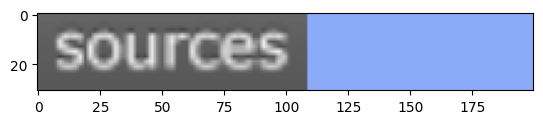

In [16]:
image, text = next(training_image_gen)
print('text:', text)
plt.imshow(image)

In [17]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=10, restore_best_weights=False),
    tf.keras.callbacks.ModelCheckpoint('recognizer_borndigital.h5', monitor='val_loss', save_best_only=True),
    tf.keras.callbacks.CSVLogger('recognizer_borndigital.csv')
]
recognizer.training_model.fit_generator(
    generator=training_gen,
    steps_per_epoch=training_steps,
    validation_steps=validation_steps,
    validation_data=validation_gen,
    callbacks=callbacks,
    epochs=1,
)

/var/folders/b6/tdv_v3m96j15zgl40jxtxn1m0000gn/T/ipykernel_14917/2768588646.py:6: UserWarning: `model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  recognizer.training_model.fit_generator(
2025-03-18 14:10:43.116222: W tensorflow/c/c_api.cc:304] Operation '{name:'bn_7/AssignMovingAvg_1/AssignSubVariableOp' id:320 op device:{requested: '', assigned: ''} def:{{{node bn_7/AssignMovingAvg_1/AssignSubVariableOp}} = AssignSubVariableOp[_class=["loc:@bn_7/moving_variance"], _has_manual_control_dependencies=true, dtype=DT_FLOAT](bn_7/moving_variance, bn_7/AssignMovingAvg_1/mul)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-18 14:10:43.192500: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device

356/356 [==============================] - ETA: 0s - batch: 177.5000 - size: 8.0000 - loss: 10.0570105 / 714 instances have illegal characters.


/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/keras/src/engine/training_v1.py:2335: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates
2025-03-18 14:43:31.366497: W tensorflow/c/c_api.cc:304] Operation '{name:'loss/mul' id:2322 op device:{requested: '', assigned: ''} def:{{{node loss/mul}} = Mul[T=DT_FLOAT, _has_manual_control_dependencies=true](loss/mul/x, loss/lambda_3_loss/value)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-18 14:43:31.455549: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/keras/src/engine/training.py:3000: UserW

356/356 [==============================] - 2003s 6s/step - batch: 177.5000 - size: 8.0000 - loss: 10.0570 - val_loss: 3.4195


2025-03-18 14:44:05.202693: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-18 14:44:05.232192: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-18 14:44:05.258402: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-18 14:44:05.284065: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-18 14:44:05.311768: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-18 14:44:05.340659: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/keras/src/engine/training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2025-03-18 14:44:10.989207: W tensorflow/c/c_api.cc:304] Operation '{name:'decode/PadV2' id:1928 op device:{requested: '', assigned: ''} def:{{{node decode/PadV2}} = PadV2[T=DT_INT64, Tpaddings=DT_INT32, _has_manual_control_dependencies=true](decode/SparseToDense, decode/PadV2/paddings, decode/PadV2/constant_values)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-18 14:44:11.083860: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Predicted: develioper, Actual: developer


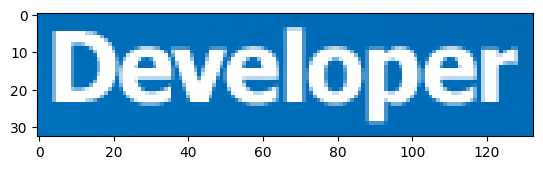

In [18]:
image_filepath, _, actual = test_labels[1]
predicted = recognizer.recognize(image_filepath)
print(f'Predicted: {predicted}, Actual: {actual}')
_ = plt.imshow(keras_ocr.tools.read(image_filepath))

## 自定义数据集

In [34]:
from utils import get_text_generator
import datetime

In [46]:
data_dir = '.'
alphabet = string.digits + string.ascii_letters + '+-×±Φφ. '
recognizer_alphabet = ''.join(sorted(set(alphabet)))
fonts = [
    './myfonts/fangsong_GB2312.ttf', 
    './myfonts/GenShinGothic-Medium.ttf', 
    './myfonts/GenShinGothic-Monospace-Normal.ttf', 
    './myfonts/GenShinGothic-Normal.ttf', 
    './myfonts/GenShinGothic-P-Normal.ttf', 
    './myfonts/GenShinGothic-Regular.ttf', 
    './myfonts/kaiti_GB2312.ttf', 
    './myfonts/msyh.ttf', 
    './myfonts/simhei.ttf', 
    './myfonts/songti.ttf'
]
backgrounds = [
    './mybackgrounds/bg1.jpg',
    './mybackgrounds/bg2.jpg',
    './mybackgrounds/bg3.jpg',
    './mybackgrounds/bg4.jpg',
    './mybackgrounds/bg5.jpg',
    './mybackgrounds/bg6.jpg',
    './mybackgrounds/bg7.jpg',
    './mybackgrounds/bg8.jpg',
    './mybackgrounds/bg9.jpg',
    './mybackgrounds/bg10.jpg',
]

# text_generator = keras_ocr.data_generation.get_text_generator(alphabet=alphabet)
text_generator = get_text_generator(alphabet=recognizer_alphabet)
print('The first generated text is:', next(text_generator))

def get_train_val_test_split(arr):
    train, valtest = sklearn.model_selection.train_test_split(arr, train_size=0.8, random_state=42)
    val, test = sklearn.model_selection.train_test_split(valtest, train_size=0.5, random_state=42)
    return train, val, test

background_splits = get_train_val_test_split(backgrounds)
font_splits = get_train_val_test_split(fonts)

image_generators = [
    keras_ocr.data_generation.get_image_generator(
        height=640,
        width=640,
        text_generator=text_generator,
        font_groups={
            alphabet: current_fonts
        },
        backgrounds=current_backgrounds,
        font_size=(60, 120),
        margin=50,
        rotationX=(-0.05, 0.05),
        rotationY=(-0.05, 0.05),
        rotationZ=(-15, 15)
    )  for current_fonts, current_backgrounds in zip(
        font_splits,
        background_splits
    )
]

The first generated text is: Φ2.7


In [47]:
recognizer_alphabet

' +-.0123456789ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz±×Φφ'

In [48]:
sentences = 'φ0.02'
for c in "".join(sentences):
    assert c in recognizer_alphabet, f"Found illegal character: {c}"

The first generated validation image (below) contains: s
biz37×8.24-3.4
1vkv


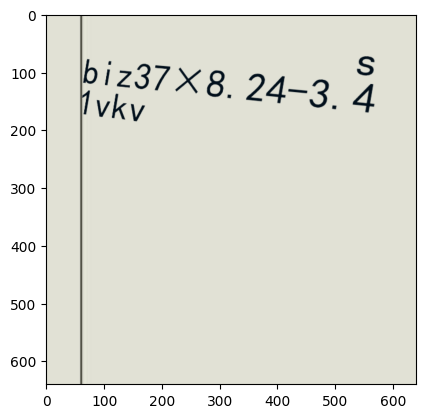

In [49]:
# See what the first validation image looks like.
image, lines = next(image_generators[1])
text = keras_ocr.data_generation.convert_lines_to_paragraph(lines)
print('The first generated validation image (below) contains:', text)
plt.imshow(image)

In [50]:
tf.compat.v1.disable_eager_execution()
tf.compat.v1.experimental.output_all_intermediates(True)
recognizer = keras_ocr.recognition.Recognizer(
    alphabet=recognizer_alphabet,
    # weights='kurapan'
)
recognizer.compile()
for layer in recognizer.backbone.layers:
    layer.trainable = False

2025-03-18 17:18:02.014255: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-18 17:18:02.063441: W tensorflow/c/c_api.cc:304] Operation '{name:'conv2d_7/bias/Assign' id:13097 op device:{requested: '', assigned: ''} def:{{{node conv2d_7/bias/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](conv2d_7/bias, conv2d_7/bias/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-18 17:18:02.304117: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-18 17:18:02.444452: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enable

Provided alphabet does not match pretrained alphabet. Using backbone weights only.
Looking for /Users/ywu/.keras-ocr/crnn_kurapan_notop.h5


2025-03-18 17:18:03.169816: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-18 17:18:03.213292: W tensorflow/c/c_api.cc:304] Operation '{name:'lstm_11_back_3/lstm_cell/recurrent_kernel/Assign' id:14335 op device:{requested: '', assigned: ''} def:{{{node lstm_11_back_3/lstm_cell/recurrent_kernel/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](lstm_11_back_3/lstm_cell/recurrent_kernel, lstm_11_back_3/lstm_cell/recurrent_kernel/Initializer/mul_1)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-18 17:18:03.513605: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-18 17:18:03.632543: I tensorflow

In [51]:
## Train the recognizer
max_length = 10
recognition_image_generators = [
    keras_ocr.data_generation.convert_image_generator_to_recognizer_input(
        image_generator=image_generator,
        max_string_length=min(recognizer.training_model.input_shape[1][1], max_length),
        target_width=recognizer.model.input_shape[2],
        target_height=recognizer.model.input_shape[1],
        margin=1
    ) for image_generator in image_generators
]

This image contains: ci7


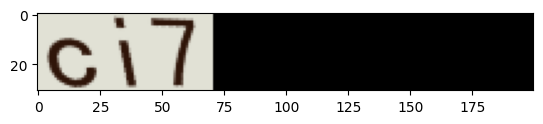

In [52]:
# See what the first validation image for recognition training looks like.
image, text = next(recognition_image_generators[1])
print('This image contains:', text)
plt.imshow(image)

In [53]:
recognition_batch_size = 8
recognizer_basepath = os.path.join(data_dir, f'recognizer_{datetime.datetime.now().isoformat()}')
recognition_train_generator, recognition_val_generator, recognition_test_generator = [
    recognizer.get_batch_generator(
    image_generator=image_generator,
    batch_size=recognition_batch_size,
    lowercase=True
    ) for image_generator in recognition_image_generators
]

recognizer.training_model.fit(
    recognition_train_generator,
    epochs=20,
    steps_per_epoch=math.ceil(len(background_splits[0]) / recognition_batch_size),
    callbacks=[
        tf.keras.callbacks.EarlyStopping(restore_best_weights=True, patience=25),
        tf.keras.callbacks.CSVLogger(f'{recognizer_basepath}.csv', append=True),
        tf.keras.callbacks.ModelCheckpoint(filepath=f'{recognizer_basepath}.h5')
    ],
    validation_data=recognition_val_generator,
    validation_steps=math.ceil(len(background_splits[1]) / recognition_batch_size),
    workers=0,
    # batch_size=recognition_batch_size
)

Epoch 1/20


2025-03-18 17:18:22.281194: W tensorflow/c/c_api.cc:304] Operation '{name:'bn_7_3/AssignMovingAvg_1/AssignSubVariableOp' id:13053 op device:{requested: '', assigned: ''} def:{{{node bn_7_3/AssignMovingAvg_1/AssignSubVariableOp}} = AssignSubVariableOp[_class=["loc:@bn_7_3/moving_variance"], _has_manual_control_dependencies=true, dtype=DT_FLOAT](bn_7_3/moving_variance, bn_7_3/AssignMovingAvg_1/mul)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-18 17:18:22.611950: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-18 17:18:22.670815: W tensorflow/c/c_api.cc:304] Operation '{name:'training_6/RMSprop/dense_6/kernel/rms/Assign' id:16048 op device:{requested: '', assigned: ''} def:{{{node training_6/RMSprop/dense_6/kernel/rms/Assign}} = A

1/1 [==============================] - ETA: 0s - batch: 0.0000e+00 - size: 8.0000 - loss: 184.9870

/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/keras/src/engine/training_v1.py:2335: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates = self.state_updates
2025-03-18 17:18:30.005795: W tensorflow/c/c_api.cc:304] Operation '{name:'loss_3/mul' id:15049 op device:{requested: '', assigned: ''} def:{{{node loss_3/mul}} = Mul[T=DT_FLOAT, _has_manual_control_dependencies=true](loss_3/mul/x, loss_3/lambda_15_loss/value)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-18 17:18:30.339452: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-03-18 17:18:31.113556: I tensorflow/core/grappler/optimizers/custom_graph_optim

1/1 [==============================] - 11s 11s/step - batch: 0.0000e+00 - size: 8.0000 - loss: 184.9870 - val_loss: 71.5723
Epoch 2/20
1/1 [==============================] - 6s 6s/step - batch: 0.0000e+00 - size: 8.0000 - loss: 75.3836 - val_loss: 12.3402
Epoch 3/20
1/1 [==============================] - 6s 6s/step - batch: 0.0000e+00 - size: 8.0000 - loss: 22.2192 - val_loss: 14.3111
Epoch 4/20
1/1 [==============================] - 6s 6s/step - batch: 0.0000e+00 - size: 8.0000 - loss: 12.9781 - val_loss: 10.2795
Epoch 5/20
1/1 [==============================] - 6s 6s/step - batch: 0.0000e+00 - size: 8.0000 - loss: 19.1948 - val_loss: 10.9620
Epoch 6/20
1/1 [==============================] - 6s 6s/step - batch: 0.0000e+00 - size: 8.0000 - loss: 16.2459 - val_loss: 11.0983
Epoch 7/20
1/1 [==============================] - 6s 6s/step - batch: 0.0000e+00 - size: 8.0000 - loss: 18.4556 - val_loss: 18.9175
Epoch 8/20
1/1 [==============================] - 6s 6s/step - batch: 0.0000e+00 - s

/opt/miniconda3/envs/ocr/lib/python3.10/site-packages/keras/src/engine/training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2025-03-18 17:20:54.660005: W tensorflow/c/c_api.cc:304] Operation '{name:'decode_3/PadV2' id:14661 op device:{requested: '', assigned: ''} def:{{{node decode_3/PadV2}} = PadV2[T=DT_INT64, Tpaddings=DT_INT32, _has_manual_control_dependencies=true](decode_3/SparseToDense, decode_3/PadV2/paddings, decode_3/PadV2/constant_values)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
2025-03-18 17:20:55.028358: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


Predicted: , Actual: developer


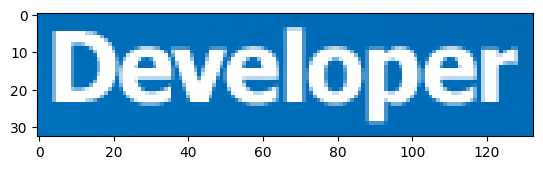

In [54]:
image_filepath, _, actual = test_labels[1]
predicted = recognizer.recognize(image_filepath)
print(f'Predicted: {predicted}, Actual: {actual}')
_ = plt.imshow(keras_ocr.tools.read(image_filepath))